In [12]:
import pandas as pd 
df = pd.read_csv("C:\econometrie2\projet S2\immobillier\ValeursFoncieres-2024.txt\ValeursFoncieres-2024.txt",
sep="|",
encoding="utf-8",
low_memory=False)
print(df.shape)
print(df.columns.tolist())

(3499931, 43)
['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain']


In [13]:
print(df.columns.tolist())

['Identifiant de document', 'Reference document', '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI', 'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere', 'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Prefixe de section', 'Section', 'No plan', 'No Volume', '1er lot', 'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot', '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot', 'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot', 'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Nature culture speciale', 'Surface terrain']


In [14]:
departements = ["75", "13", "69", "31", "06", "44", "34", "67", "33", "59"]
df_villes = df[df["Code departement"].isin(departements)].copy()
print(df_villes.shape)
print(df_villes["Code departement"].value_counts())

(697551, 43)
Code departement
59    95707
33    82927
13    81098
06    77211
69    75985
75    74800
44    73325
34    69651
31    66847
Name: count, dtype: int64


In [15]:
departements = ["75", "13", "69", "31", "06", "44", "34", "67", "33", "59"]
df_villes = df[df["Code departement"].isin(departements)].copy()
df_villes = df_villes[df_villes["Type local"].isin(["Appartement", "Maison"])]
df_villes["Valeur fonciere"] = df_villes["Valeur fonciere"].astype(str).str.replace(",", ".").str.replace(" ", "")
df_villes["Valeur fonciere"] = pd.to_numeric(df_villes["Valeur fonciere"], errors="coerce")
df_villes["Surface reelle bati"] = pd.to_numeric(df_villes["Surface reelle bati"], errors="coerce")
df_villes["Prix au m2"] = df_villes["Valeur fonciere"] / df_villes["Surface reelle bati"]
df_villes = df_villes.dropna(subset=["Valeur fonciere", "Surface reelle bati", "Prix au m2"])
df_villes = df_villes[df_villes["Prix au m2"] > 500]
df_villes = df_villes[df_villes["Prix au m2"] < 50000]
mapping_villes = {
    "75": "Paris", "13": "Marseille", "69": "Lyon",
    "31": "Toulouse", "06": "Nice", "44": "Nantes",
    "34": "Montpellier", "67": "Strasbourg", "33": "Bordeaux", "59": "Lille"
}
df_villes["Ville"] = df_villes["Code departement"].map(mapping_villes)
print(df_villes.shape)

(224795, 45)


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns 
df_villes["Date mutation"] = pd.to_datetime(df_villes["Date mutation"],dayfirst=True)
df_villes["Mois"] = df_villes["Date mutation"].dt.month
print(df_villes["Mois"].value_counts().sort_index())
print("\nPrix moyen dans les 10 plus grandes villes francaises :", round(df_villes["Prix au m2"].mean(), 0), "€")

Mois
1     15240
2     15228
3     16003
4     17261
5     16810
6     20234
7     25111
8     15766
9     21639
10    20992
11    16722
12    23789
Name: count, dtype: int64

Prix moyen dans les 10 plus grandes villes francaises : 5406.0 €


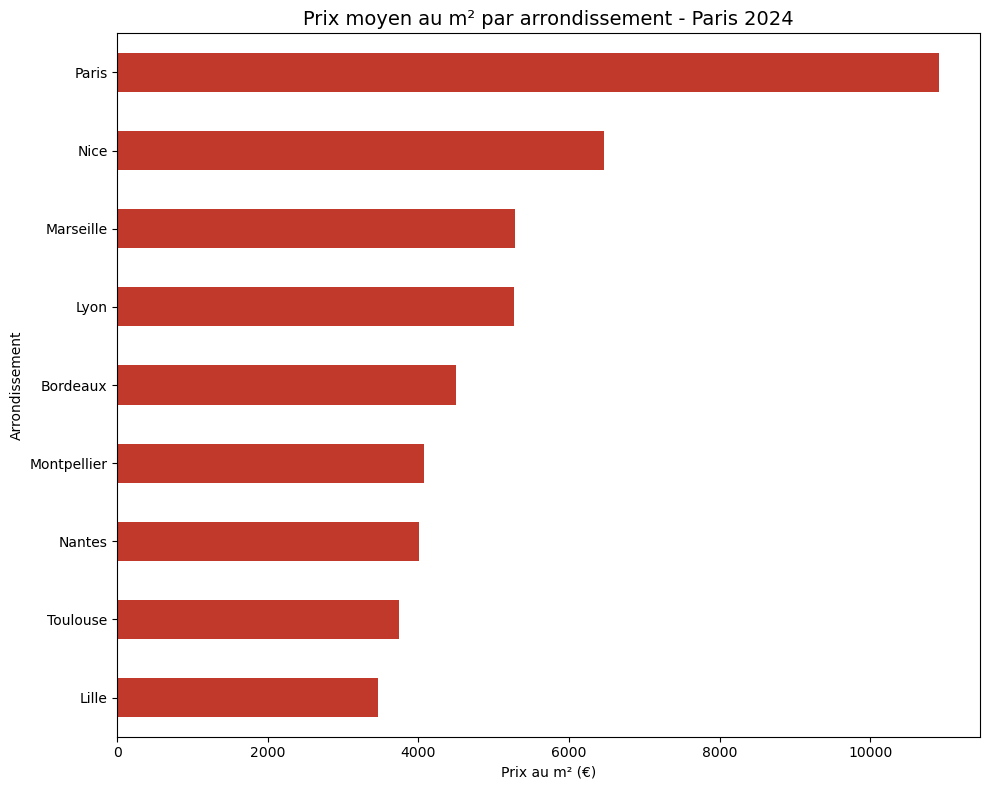

In [17]:
prix_par_villes = df_villes.groupby("Ville")["Prix au m2"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
prix_par_villes.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Prix moyen au m² par arrondissement - Paris 2024", fontsize=14)
ax.set_xlabel("Prix au m² (€)")
ax.set_ylabel("Arrondissement")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("prix_par_villes.png", dpi=150)
plt.show()

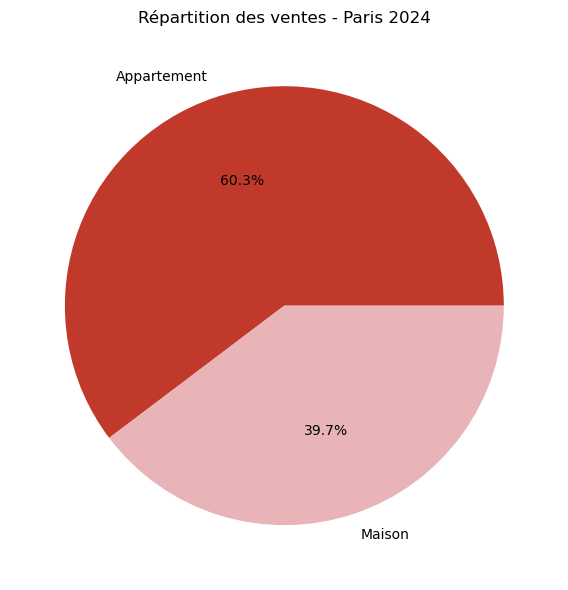

In [18]:
repartition = df_villes["Type local"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
repartition.plot(kind="pie", ax=ax, autopct="%1.1f%%", colors=["#c0392b", "#e8b4b8"])
ax.set_title("Répartition des ventes - Paris 2024")
ax.set_ylabel("")  
plt.tight_layout()
plt.savefig("repartition_types.png", dpi=150)
plt.show()

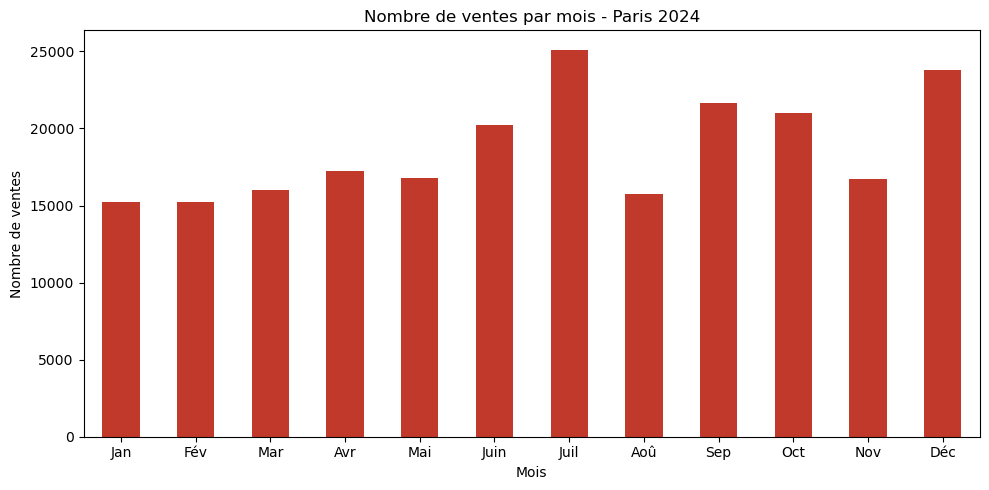

In [19]:
ventes_par_mois = df_villes.groupby("Mois")["Valeur fonciere"].count()
mois_noms = {1:"Jan", 2:"Fév", 3:"Mar", 4:"Avr", 5:"Mai", 6:"Juin",
             7:"Juil", 8:"Aoû", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Déc"}
ventes_par_mois.index = ventes_par_mois.index.map(mois_noms)
fig, ax = plt.subplots(figsize=(10, 5))
ventes_par_mois.plot(kind="bar", ax=ax, color="#c0392b")
ax.set_title("Nombre de ventes par mois - Paris 2024")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de ventes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("ventes_par_mois.png", dpi=150)
plt.show()

In [20]:
colonnes_utiles = ["Date mutation", "Ville", "Type local", 
                   "Valeur fonciere", "Surface reelle bati", 
                   "Prix au m2", "Nombre pieces principales", "Mois"]
df_export = df_villes[colonnes_utiles].copy()
df_export.to_csv("immobilier_10villes_2024.csv", index=False, sep=",", decimal=".")
print("Fais :", df_export.shape)

Fais : (224795, 8)


In [21]:
colonnes_utiles = ["Date mutation", "Ville", "Type local", 
                   "Valeur fonciere", "Surface reelle bati", 
                   "Prix au m2", "Nombre pieces principales", "Mois"]
df_export = df_villes[colonnes_utiles].copy()
df_export["Prix au m2"] = df_export["Prix au m2"].round(2)
df_export["Valeur fonciere"] = df_export["Valeur fonciere"].round(2)
df_export["Surface reelle bati"] = df_export["Surface reelle bati"].round(2)
df_export.to_csv("immobilier_paris_2024.csv", index=False, sep=",", decimal=".")
print("Export terminé :", df_export.shape)

Export terminé : (224795, 8)
